# ODE for generative modeling

The notebook implements generative modeling with an ordinary differential equation (ODE)
for a latent variable $x_t$, $t\in [0,1]$:
\begin{align*}
x_0 & \sim p_0(x_0)\\ dx & = f(x,t) dt \\ y & = x_1 
\end{align*}
with the prior being a standard Gaussian: $p_0(x_0)=\mathcal{N}(x_0|0,1)$.

We simulate data from a known one-dimensional distribution and learn the drift $f(x,t)$,
parameterized as a neural network, by maximizing the exact log-likelihood.

The solution of the ODE at time $t$ initialised in $x_s$ at time $s$ can be expressed in terms of the *flow map* $\phi_s^t(x_s)$. The flow map obeys the ODE: $\frac{d}{d t} \phi_s^t(x_s) = f(\phi_s^t(x_s),t)$ with the condition $\phi_t^t(x)=x$. 

In the exact log-likelihood:
$$
\log p(y) = \log p_0(\phi^0_1(y)) - \int_0^1 \frac{\partial f(\phi^t_1(y),t)}{\partial \phi^t_1} dt \ ,
$$
which follows from the instantaneous change-of-variables formula,
we integrate the ODE backwards from the data at $t=1$ using the flow map $\phi^t_1(y)$. 

The log likelihood calculation therefore requires numerical integration of both the ODE and partial derivative of the drift. Euler and Runge-Kutta methods are used for this.  


## Setup

In [1]:
import os, sys

try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    os.system("wget -q https://raw.githubusercontent.com/olewinther/generative-ode-sde/main/utils.py")
else:
    for path in ['..', '.']:
        if os.path.exists(os.path.join(path, 'utils.py')):
            sys.path.insert(0, os.path.abspath(path))
            break

from utils import *

## GPU

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'
print('GPU State:', device)

GPU State: cpu


## Drift network

In [3]:
import torch.nn as nn

class DriftNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1),
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=-1))

In [4]:
def plot_f(f_net, num_samples=3):
    t_grid = torch.linspace(0, 1, 100).unsqueeze(1)
    x_samples = torch.randn(num_samples, 1)

    fig, ax = plt.subplots(figsize=(10, 3))
    for s in x_samples:
        with torch.no_grad():
            vals = [f_net(s, t.expand_as(s)).item() for t in t_grid]
        ax.plot(t_grid.numpy(), vals, label=f"x={s.item():.2f}")
    ax.set_title("f(x,t)"); ax.set_xlabel("t"); ax.set_ylabel("f(x,t)"); ax.legend()
    plt.tight_layout(); plt.show()

## ODE simulation, log-likelihood, and training loop

In [ ]:
def partial_drift_x(ode_func, x, t):
    x.requires_grad_(True)
    drift = ode_func(x, t)
    return torch.autograd.grad(drift, x, grad_outputs=torch.ones_like(drift), create_graph=True)[0]


def simulate_ode(ode_func, x_start, t, method="euler", reverse=False):
    """Simulate the coupled (state, log-prob) ODE system."""
    x = x_start
    log_likelihood = torch.zeros(x.size(0))
    state = torch.cat([x, log_likelihood.unsqueeze(1)], dim=1)
    dt = t[1] - t[0]
    dt = -dt if reverse else dt

    def derivatives(state, t_i):
        x = state[:, :-1]
        x.requires_grad_()
        t_i = t_i.expand_as(x)
        drift = ode_func(x, t_i)
        div = torch.autograd.grad(drift, x, grad_outputs=torch.ones_like(drift), create_graph=True)[0]
        return torch.cat([drift, -div], dim=1)

    def step(method, state, t_i, dt):
        if method == "euler":
            return state + derivatives(state, t_i) * dt
        elif method == "rk2":
            k1 = derivatives(state, t_i)
            return state + dt * derivatives(state + 0.5 * dt * k1, t_i + 0.5 * dt)
        elif method == "rk4":
            k1 = derivatives(state, t_i)
            k2 = derivatives(state + 0.5 * dt * k1, t_i + 0.5 * dt)
            k3 = derivatives(state + 0.5 * dt * k2, t_i + 0.5 * dt)
            k4 = derivatives(state + dt * k3, t_i + dt)
            return state + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        raise ValueError(f"Unknown method: {method}")

    time_points = list(reversed(t[:-1])) if reverse else list(t[:-1])
    for t_i in time_points:
        t_i = t_i.expand_as(x)
        state = step(method, state, t_i, dt)
        x = state[:, :-1]

    log_likelihood = state[:, -1]
    if reverse:
        log_likelihood = -log_likelihood
    return state[:, :-1], log_likelihood


def compute_log_likelihood_ode(ode_func, prior, training_data, t, method="euler"):
    x1 = training_data
    x0, log_likelihood_term = simulate_ode(ode_func, x1, t, method=method, reverse=True)
    prior_log_prob = prior.log_prob(x0).squeeze()
    return (prior_log_prob + log_likelihood_term).mean()


def training_loop_ode(f_net, prior, data_loader, validation_data, t, method="euler", n_epochs=1000, lr=1e-3):
    from collections import deque
    optimizer = torch.optim.Adam(f_net.parameters(), lr=lr)
    train_history, val_history = deque(maxlen=5), deque(maxlen=5)
    for epoch in range(n_epochs):
        total_loglike = 0.0
        for y_batch in data_loader:
            optimizer.zero_grad()
            loglike = compute_log_likelihood_ode(f_net, prior, y_batch, t, method=method)
            total_loglike += loglike.item()
            (-loglike).backward()
            optimizer.step()
        if epoch % 10 == 0 or epoch == n_epochs - 1:
            loglike_val = compute_log_likelihood_ode(f_net, prior, validation_data, t, method=method)
            loglike_val_rk4 = compute_log_likelihood_ode(f_net, prior, validation_data, t, method="rk4")
            train_cur = total_loglike / len(data_loader)
            val_cur = loglike_val.item()
            train_history.append(train_cur)
            val_history.append(val_cur)
            avg_train = sum(train_history) / len(train_history)
            avg_val = sum(val_history) / len(val_history)
            print(f"Epoch {epoch:4d} | train {train_cur:.4f} (avg {avg_train:.4f}) | "
                  f"val {val_cur:.4f} (avg {avg_val:.4f}) | val(rk4) {loglike_val_rk4:.4f}")
    return f_net

## Create training and validation data

In [6]:
torch.manual_seed(42)
np.random.seed(42)

n_samples, n_val = 1000, 8000

# Choose distribution: 'gaussian', 'laplace', 'laplace_mixture'
training_set_dist = 'laplace_mixture'

if training_set_dist == 'gaussian':
    params = {'mean': torch.tensor(-1.0), 'std': torch.tensor(2.0)}
elif training_set_dist == 'laplace':
    params = {'loc': torch.tensor(0.0), 'scale': torch.tensor(1.0)}
elif training_set_dist == 'laplace_mixture':
    params = {'k': 5, 'spacing': 4.0, 'scale': torch.tensor(1.0)}

training_set = TrainingSetWithLogLikelihood(training_set_dist, params)
training_data, ell_train = training_set.generate_training_data(n_samples)
validation_data, ell_val = training_set.generate_training_data(n_val)
print(f"{training_set_dist} | true log-likelihood: train={ell_train:.4f}, val={ell_val:.4f}")

laplace_mixture | true log-likelihood: train=-2.9829, val=-2.9862


## Run training

Before training:


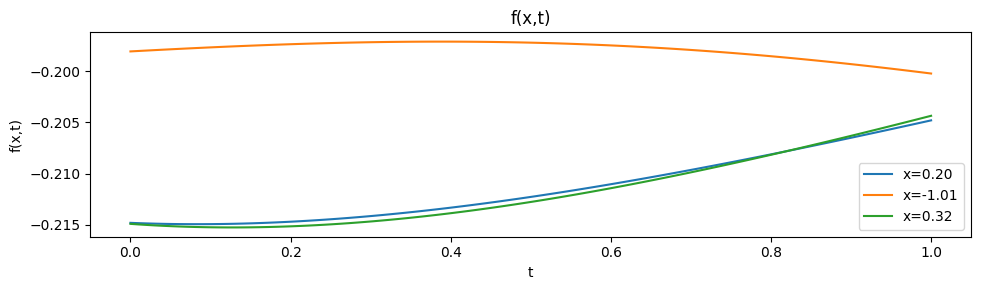

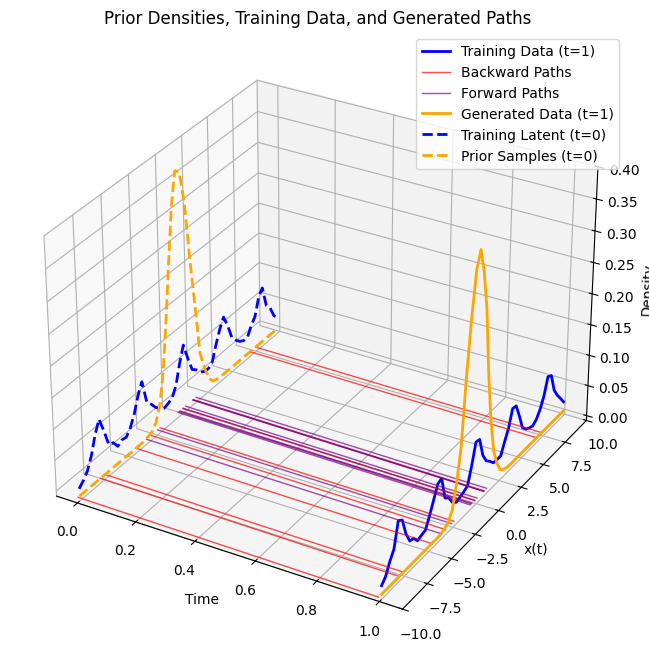

Epoch    0 | train -7.2210 | val -4.5339 | val(rk4) -4.5338
Epoch   10 | train -3.0877 | val -3.0935 | val(rk4) -3.0935
Epoch   20 | train -3.0777 | val -3.0851 | val(rk4) -3.0851
Epoch   30 | train -3.0698 | val -3.0755 | val(rk4) -3.0754
Epoch   40 | train -3.0669 | val -3.0695 | val(rk4) -3.0695
Epoch   50 | train -3.0546 | val -3.0615 | val(rk4) -3.0614
Epoch   60 | train -3.0487 | val -3.0529 | val(rk4) -3.0528
Epoch   70 | train -3.0500 | val -3.0632 | val(rk4) -3.0631
Epoch   80 | train -3.0355 | val -3.0507 | val(rk4) -3.0506
Epoch   90 | train -3.0339 | val -3.0432 | val(rk4) -3.0430
Epoch  100 | train -3.0213 | val -3.0366 | val(rk4) -3.0364
Epoch  110 | train -3.0126 | val -3.0413 | val(rk4) -3.0411
Epoch  120 | train -3.0209 | val -3.0302 | val(rk4) -3.0299
Epoch  130 | train -3.0100 | val -3.0237 | val(rk4) -3.0233
Epoch  140 | train -3.0165 | val -3.0286 | val(rk4) -3.0281
Epoch  150 | train -3.0007 | val -3.0567 | val(rk4) -3.0561
Epoch  160 | train -2.9930 | val -3.0178

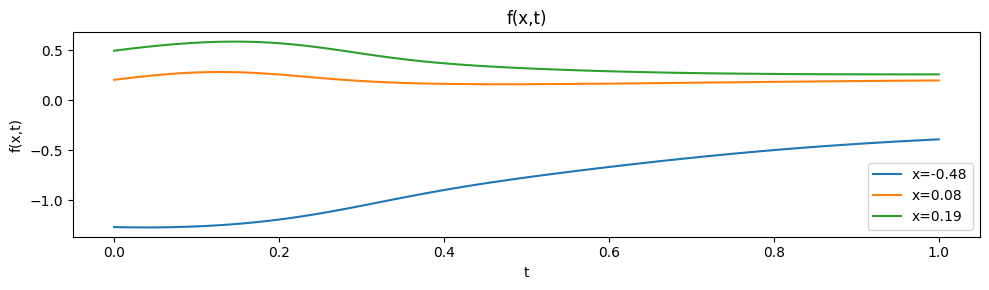

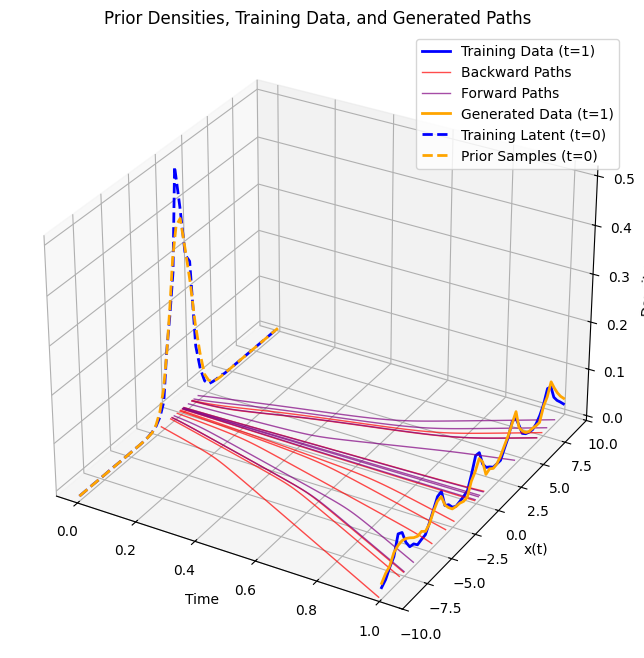

In [8]:
data_loader = torch.utils.data.DataLoader(training_data, batch_size=125, shuffle=True)

f_net = DriftNetwork()
prior = Prior(gaussian_sample, gaussian_log_pdf)
t = torch.linspace(0, 1, steps=100)

forward_path  = ForwardPath(mode="ode", f_net=f_net, prior=prior)
backward_path = BackwardPath(mode="ode", f_net=f_net)

print("Before training:")
plot_f(f_net)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)

trained_f_net = training_loop_ode(
    f_net, prior, data_loader, validation_data,
    t=t, method="rk2", n_epochs=200, lr=1e-2,
)

print("After training:")
plot_f(f_net)
visualize_paths_and_marginals(validation_data, t, backward_path, forward_path)